# Introduction
In this notebook, we explore multiple movie-related datasets to understand their structure and prepare them for further analysis. This includes data from **TMDb**, **The Numbers**, **Box Office Mojo**, and **Rotten Tomatoes**.

In this project we will perform the following operatons:
- Get an initial overview of each dataset 
- Understand the structure and quality of the data
- Perform Exploratory Data Analysis using Pandas on the datasets and draw visualizations


# Business Understanding
My company has descided to venture into the movie industry, more specifically they want to create their own movie studio. We are tasked with exploring what types of films are currently doing the best using the datasets listed previously. We must then translate those findings into actionable insights that the head of our company's new movie studio can use to help decide what type of films to create.

# Objectives 
The main objectives for the study are:

1.**Quantify Movie Profitability** Use financial data (production budgets and worldwide gross) to compute Return on Investment (ROI) and identify the most and least profitable films.

2.**Analyze Movie Ratings** Explore ratings data to understand if and how factors such as runtime, publisher influence critical scores and genre correlate to movie ratings.

3.**Find blockbuster movies globally** We find movies that performed exceptionally not only domestically but also worldwide using the worldwide_gross data

4.**Investigate the runtime vs movie rating** Find out the average runtime and if it has any influence on movie ratings. 

# 1.Getting a brief overview of the datasets

First we import the relevant python libraries and loading the datasets.
- `tmdb_movies`: Movies from The Movie Database (TMDb)
- `tn_movie_budgets`: Budget and revenue data from The Numbers
- `rt_reviews`: Movie reviews from Rotten Tomatoes
- `rt_movie_info`: Additional Rotten Tomatoes metadata
- `boom_movie`: Gross earnings from Box Office Mojo

We explore each dataset using the imported libraries to get a glimpse of the columns present in each dataset as the shapes of the DataFrames present using methods such as; `.head()`, `.info()`, and `.tail()`.This gives us a brief understanding of what each dataset entails.

In [2]:
import pandas as pd
import sqlite3
conn=sqlite3.connect("unzipped_im.bd")
tmdb_movies = pd.read_csv('tmdb.movies.csv')
tn_movie_budgets=pd.read_csv('tn.movie_budgets.csv')
rt_reviews = pd.read_csv('rt.reviews.tsv', sep='\t',encoding='latin-1')
rt_movie_info=pd.read_csv('rt.movie_info.tsv',sep='\t',encoding='latin-1')
boom_movie=pd.read_csv('bom.movie_gross.csv')

In [3]:
tn_movie_budgets.tail()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
5777,78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
5778,79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
5779,80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"
5780,81,"Sep 29, 2015",A Plague So Pleasant,"$1,400",$0,$0
5781,82,"Aug 5, 2005",My Date With Drew,"$1,100","$181,041","$181,041"


In [4]:
tn_movie_budgets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   movie              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 271.2+ KB


In [5]:
boom_movie

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010
...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018


In [6]:
boom_movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


In [7]:
tmdb_movies.head(50)

,Unnamed: 0,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186
5,5,"[12, 14, 10751]",32657,en,Percy Jackson & the Olympians: The Lightning T...,26.691,2010-02-11,Percy Jackson & the Olympians: The Lightning T...,6.1,4229
6,6,"[28, 12, 14, 878]",19995,en,Avatar,26.526,2009-12-18,Avatar,7.4,18676
7,7,"[16, 10751, 35]",10193,en,Toy Story 3,24.445,2010-06-17,Toy Story 3,7.7,8340
8,8,"[16, 10751, 35]",20352,en,Despicable Me,23.673,2010-07-09,Despicable Me,7.2,10057
9,9,"[16, 28, 35, 10751, 878]",38055,en,Megamind,22.855,2010-11-04,Megamind,6.8,3635


In [8]:
tmdb_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26517 entries, 0 to 26516
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         26517 non-null  int64  
 1   genre_ids          26517 non-null  object 
 2   id                 26517 non-null  int64  
 3   original_language  26517 non-null  object 
 4   original_title     26517 non-null  object 
 5   popularity         26517 non-null  float64
 6   release_date       26517 non-null  object 
 7   title              26517 non-null  object 
 8   vote_average       26517 non-null  float64
 9   vote_count         26517 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 2.0+ MB


In [9]:
rt_reviews.head(50)

,id,review,rating,fresh,critic,top_critic,publisher,date
0,3,A distinctly gallows take on contemporary fina...,3/5,fresh,PJ Nabarro,0,Patrick Nabarro,"November 10, 2018"
1,3,It's an allegory in search of a meaning that n...,NaN,rotten,Annalee Newitz,0,io9.com,"May 23, 2018"
2,3,... life lived in a bubble in financial dealin...,NaN,fresh,Sean Axmaker,0,Stream on Demand,"January 4, 2018"
3,3,Continuing along a line introduced in last yea...,NaN,fresh,Daniel Kasman,0,MUBI,"November 16, 2017"
4,3,... a perverse twist on neorealism...,NaN,fresh,NaN,0,Cinema Scope,"October 12, 2017"
5,3,... Cronenberg's Cosmopolis expresses somethin...,NaN,fresh,Michelle Orange,0,Capital New York,"September 11, 2017"
6,3,"Quickly grows repetitive and tiresome, meander...",C,rotten,Eric D. Snider,0,EricDSnider.com,"July 17, 2013"
7,3,Cronenberg is not a director to be daunted by ...,2/5,rotten,Matt Kelemen,0,Las Vegas CityLife,"April 21, 2013"
8,3,"Cronenberg's cold, exacting precision and emot...",NaN,fresh,Sean Axmaker,0,Parallax View,"March 24, 2013"
9,3,Over and above its topical urgency or the bit ...,NaN,fresh,Kong Rithdee,0,Bangkok Post,"March 4, 2013"


In [10]:
rt_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54432 entries, 0 to 54431
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          54432 non-null  int64 
 1   review      48869 non-null  object
 2   rating      40915 non-null  object
 3   fresh       54432 non-null  object
 4   critic      51710 non-null  object
 5   top_critic  54432 non-null  int64 
 6   publisher   54123 non-null  object
 7   date        54432 non-null  object
dtypes: int64(2), object(6)
memory usage: 3.3+ MB


In [11]:
#checking the summary of first 20 rows
rt_movie_info.tail()

,id,synopsis,rating,genre,director,writer,theater_date,dvd_date,currency,box_office,runtime,studio
1555,1996,Forget terrorists or hijackers -- there's a ha...,R,Action and Adventure|Horror|Mystery and Suspense,NaN,NaN,"Aug 18, 2006","Jan 2, 2007",$,"33,886,034",106 minutes,New Line Cinema
1556,1997,The popular Saturday Night Live sketch was exp...,PG,Comedy|Science Fiction and Fantasy,Steve Barron,Terry Turner|Tom Davis|Dan Aykroyd|Bonnie Turner,"Jul 23, 1993","Apr 17, 2001",NaN,NaN,88 minutes,Paramount Vantage
1557,1998,"Based on a novel by Richard Powell, when the l...",G,Classics|Comedy|Drama|Musical and Performing Arts,Gordon Douglas,NaN,"Jan 1, 1962","May 11, 2004",NaN,NaN,111 minutes,NaN
1558,1999,The Sandlot is a coming-of-age story about a g...,PG,Comedy|Drama|Kids and Family|Sports and Fitness,David Mickey Evans,David Mickey Evans|Robert Gunter,"Apr 1, 1993","Jan 29, 2002",NaN,NaN,101 minutes,NaN
1559,2000,"Suspended from the force, Paris cop Hubert is ...",R,Action and Adventure|Art House and Internation...,NaN,Luc Besson,"Sep 27, 2001","Feb 11, 2003",NaN,NaN,94 minutes,Columbia Pictures


In [12]:
pd.read_sql("""SELECT *
            FROM sqlite_master
            WHERE type='table';
            """,conn )

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


# 2. Data cleaning 
In order to perform calculations and visualizations thereafter we first prepare our raw data. We remove missing values. We drop irrelevant columns and merge some datasets with common columns to get a comprehensive view. This is the data cleaning process outlined in the following cells.

## Cleaning Financial Figures

Some columns in the `tn_movie_budgets` dataset (e.g., `production_budget`, `worldwide_gross`, `domestic_gross`) were outlined as strings with currency symbols and commas, making them unsuitable for numerical calculations.

We cleaned these columns by:
- Removing dollar signs (`$`) and commas (`,`) using regex
- Converting them to `float` data type for numerical analysis

This step is essential for accurate financial comparisons and computations.

In [13]:
# cleaning the tn_movie_budgets dataset
tn_movie_budgets['production_budget'] = tn_movie_budgets['production_budget'].replace('[\$,]', '', regex=True).astype(float)
tn_movie_budgets['production_budget']

0       425000000.0
1       410600000.0
2       350000000.0
3       330600000.0
4       317000000.0
           ...     
5777         7000.0
5778         6000.0
5779         5000.0
5780         1400.0
5781         1100.0
Name: production_budget, Length: 5782, dtype: float64

In [14]:
tn_movie_budgets['worldwide_gross'] = tn_movie_budgets['worldwide_gross'].replace('[\$,]', '', regex=True).astype(float)
tn_movie_budgets['worldwide_gross']

0       2.776345e+09
1       1.045664e+09
2       1.497624e+08
3       1.403014e+09
4       1.316722e+09
            ...     
5777    0.000000e+00
5778    2.404950e+05
5779    1.338000e+03
5780    0.000000e+00
5781    1.810410e+05
Name: worldwide_gross, Length: 5782, dtype: float64

## Calculating the rate of investment
We created a new metric — **Return on Investment (ROI)** — to quantify how profitable each movie was relative to its production budget. This is an exponent of how many times the profit exceeded the budget used for producing the movie.

ROI is calculated as:

\[
ROI = \frac{\text{worldwide gross} - \text{production budget}}{\text{production budget}}
\]

- **ROI > 0** ➔ Profit
- **ROI < 0** ➔ Loss
- **ROI = 1** ➔ Doubled its budget

This allows us to rank movies by profitability rather than raw revenue.


In [15]:
# Calculating the Return on Investment(ROI)
tn_movie_budgets['ROI'] = (tn_movie_budgets['worldwide_gross'] - tn_movie_budgets['production_budget']) / tn_movie_budgets['production_budget']
tn_movie_budgets['ROI']

0         5.532577
1         1.546673
2        -0.572108
3         3.243841
4         3.153696
           ...    
5777     -1.000000
5778     39.082500
5779     -0.732400
5780     -1.000000
5781    163.582727
Name: ROI, Length: 5782, dtype: float64

##  Most and Least Profitable Movies

After calculating ROI, we sorted the dataset to find:
- Top 10 most profitable movies
- Bottom 10 least profitable movies

This gives us insight into what kinds of films yield the highest returns — potentially lower-budget films with high gross returns.


In [16]:
#checking the top 10 profitable movies in ascending order
top_10_profitable = tn_movie_budgets.sort_values(by='ROI', ascending=False).head(10)
top_10_profitable

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,ROI
5745,46,"Jun 30, 1972",Deep Throat,25000.0,"$45,000,000",45000000.0,1799.000000
5613,14,"Mar 21, 1980",Mad Max,200000.0,"$8,750,000",99750000.0,497.750000
5492,93,"Sep 25, 2009",Paranormal Activity,450000.0,"$107,918,810",194183034.0,430.517853
5679,80,"Jul 10, 2015",The Gallows,100000.0,"$22,764,410",41656474.0,415.564740
5406,7,"Jul 14, 1999",The Blair Witch Project,600000.0,"$140,539,099",248300000.0,412.833333
5709,10,"May 7, 2004",Super Size Me,65000.0,"$11,529,368",22233808.0,341.058585
5346,47,"Aug 13, 1942",Bambi,858000.0,"$102,797,000",268000000.0,311.354312
5773,74,"Feb 26, 1993",El Mariachi,7000.0,"$2,040,920",2041928.0,290.704000
5676,77,"Oct 1, 1968",Night of the Living Dead,114000.0,"$12,087,064",30087064.0,262.921614
5210,11,"Nov 21, 1976",Rocky,1000000.0,"$117,235,147",225000000.0,224.000000


In [17]:
#checking the movies with least profit
bottom_10_profitable = tn_movie_budgets.sort_values(by='ROI', ascending=True).head(10)
bottom_10_profitable

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,ROI
5712,13,"Dec 31, 2012",Hayride,60000.0,$0,0.0,-1.0
5753,54,"Dec 31, 2014",Dry Spell,22000.0,$0,0.0,-1.0
2754,55,"Mar 8, 2016",Out of the Inferno,19000000.0,$0,0.0,-1.0
5318,19,"Feb 10, 2015",Fear Clinic,1000000.0,$0,0.0,-1.0
5319,20,"Mar 10, 2015",The Pet,1000000.0,$0,0.0,-1.0
5593,94,"Dec 31, 2010",The Christmas Bunny,250000.0,$0,0.0,-1.0
2011,12,"Dec 31, 2003",Ripley's Game,30000000.0,$0,0.0,-1.0
5472,73,"Apr 3, 2012",Enter Nowhere,500000.0,$0,0.0,-1.0
5320,21,"Dec 31, 2014",Bang Bang Baby,1000000.0,$0,0.0,-1.0
3162,63,"Jun 29, 2001",Pandaemonium,15000000.0,$0,0.0,-1.0


In [18]:
tmdb_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26517 entries, 0 to 26516
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         26517 non-null  int64  
 1   genre_ids          26517 non-null  object 
 2   id                 26517 non-null  int64  
 3   original_language  26517 non-null  object 
 4   original_title     26517 non-null  object 
 5   popularity         26517 non-null  float64
 6   release_date       26517 non-null  object 
 7   title              26517 non-null  object 
 8   vote_average       26517 non-null  float64
 9   vote_count         26517 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 2.0+ MB


## Merging Movie Datasets

 We merged the `tmdb_movies` and `tn_movie_budgets` datasets using cleaned and lowercase movie titles.

This combined dataset allows for more comprehensive analysis by utilizing the attributes from TMDb and the financial details from The Numbers.


In [19]:
# Cleaning the movie tittles to make sure there are no spaces and lowercases
tmdb_movies['title'] = tmdb_movies['title'].str.strip().str.lower()
tmdb_movies['title']

0        harry potter and the deathly hallows: part 1
1                            how to train your dragon
2                                          iron man 2
3                                           toy story
4                                           inception
                             ...                     
26512                           laboratory conditions
26513                                 _exhibit_84xxx_
26514                                    the last one
26515                                    trailer made
26516                                      the church
Name: title, Length: 26517, dtype: object

In [20]:
# Merge on title
merged = pd.merge(tmdb_movies, tn_movie_budgets, left_on='title', right_on='movie', how='inner')
merged

,Unnamed: 0,genre_ids,id_x,original_language,original_title,popularity,release_date_x,title,vote_average,vote_count,id_y,release_date_y,movie,production_budget,domestic_gross,worldwide_gross,ROI
0,2556,"[35, 18]",40807,en,50/50,12.451,2011-09-30,50/50,7.1,2111,73,"Sep 30, 2011",50/50,8000000.0,"$35,016,118",41334735.0,4.166842
1,7989,[18],109410,en,42,11.280,2013-04-12,42,7.0,1028,22,"Apr 12, 2013",42,31000000.0,"$95,020,213",97470701.0,2.144216
2,9404,[99],501497,ja,2012,1.156,2013-03-21,2012,4.0,2,59,"Nov 13, 2009",2012,200000000.0,"$166,112,167",757677748.0,2.788389
3,10228,[18],215918,en,1982,0.600,2013-12-31,1982,7.5,2,23,"Mar 1, 2016",1982,1000000.0,$0,0.0,-1.000000
4,11868,"[35, 18]",197583,en,50 to 1,2.852,2014-03-21,50 to 1,6.2,25,93,"Mar 21, 2014",50 to 1,10000000.0,"$1,069,454",1069454.0,-0.893055
5,14330,[35],11519,en,1941,9.755,1979-12-14,1941,5.7,262,4,"Dec 14, 1979",1941,32000000.0,"$34,175,000",94875000.0,1.964844
6,17667,"[27, 53, 9648]",284564,en,31,8.683,2016-10-21,31,5.2,370,85,"Oct 21, 2016",31,1500000.0,"$779,820",922727.0,-0.384849
7,20707,"[18, 27, 9648]",381283,en,mother!,15.227,2017-09-15,mother!,7.0,3458,59,"Sep 15, 2017",mother!,30000000.0,"$17,800,004",42531076.0,0.417703
8,25581,"[27, 9648, 53]",477577,en,3,1.816,2018-08-07,3,6.0,2,85,"Sep 16, 2011",3,7200000.0,"$59,774",295492.0,-0.958959


# 3. Visualizations
  In order to observe trends and patterns from the datasets we construct various visualizations that will help to provide insights later on. We imported the various python libraries required for plotting.

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


## 📊  Top 10 Profitable Movies

We visualized the **production budgets vs. worldwide gross** for the top 10 profitable movies using a dual bar chart. This helped us visually assess:
- How some lower-budget films generated high revenue
- Which movies had high budgets but even higher grosses

**NOTE**- We plotted production budget with worldwide gross instead of ROI since it is an exponent/percentage whereas budget is a raw figure which would have given an poor visualization.


**Visualization of financial data using profit**

In [22]:
tn_movie_budgets['profit'] = tn_movie_budgets['worldwide_gross'] - tn_movie_budgets['production_budget']
tn_movie_budgets


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,ROI,profit
0,1,"Dec 18, 2009",Avatar,425000000.0,"$760,507,625",2.776345e+09,5.532577,2.351345e+09
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,410600000.0,"$241,063,875",1.045664e+09,1.546673,6.350639e+08
2,3,"Jun 7, 2019",Dark Phoenix,350000000.0,"$42,762,350",1.497624e+08,-0.572108,-2.002376e+08
3,4,"May 1, 2015",Avengers: Age of Ultron,330600000.0,"$459,005,868",1.403014e+09,3.243841,1.072414e+09
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,317000000.0,"$620,181,382",1.316722e+09,3.153696,9.997217e+08
...,...,...,...,...,...,...,...,...
5777,78,"Dec 31, 2018",Red 11,7000.0,$0,0.000000e+00,-1.000000,-7.000000e+03
5778,79,"Apr 2, 1999",Following,6000.0,"$48,482",2.404950e+05,39.082500,2.344950e+05
5779,80,"Jul 13, 2005",Return to the Land of Wonders,5000.0,"$1,338",1.338000e+03,-0.732400,-3.662000e+03
5780,81,"Sep 29, 2015",A Plague So Pleasant,1400.0,$0,0.000000e+00,-1.000000,-1.400000e+03


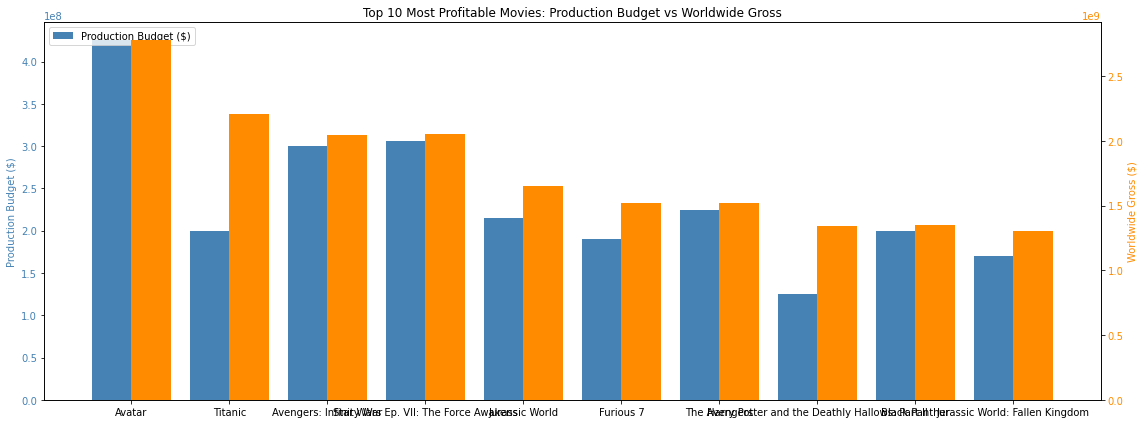

In [23]:

top_10_profitable = tn_movie_budgets.sort_values(by='profit', ascending=False).head(10)
movies = top_10_profitable['movie']
budget = top_10_profitable['production_budget']
gross = top_10_profitable['worldwide_gross']

x = np.arange(len(movies))
width = 0.4

fig, ax1 = plt.subplots(figsize=(16, 6))

bar1 = ax1.bar(x - width/2, budget, width, label='Production Budget ($)', color='steelblue')
ax1.set_ylabel('Production Budget ($)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
bar2 = ax2.bar(x + width/2, gross, width, label='Worldwide Gross ($)', color='darkorange')
ax2.set_ylabel('Worldwide Gross ($)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.xticks(x, movies, rotation=75)
plt.title('Top 10 Most Profitable Movies: Production Budget vs Worldwide Gross')

ax1.legend(loc='upper left')

fig.tight_layout()
plt.show()


**Visualization of financial data using ROI**

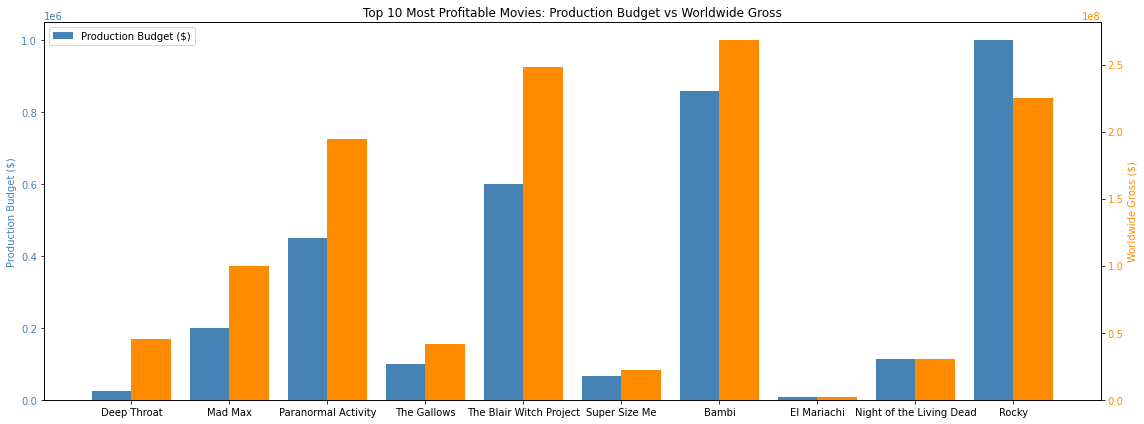

In [24]:
top_10_profitable = tn_movie_budgets.sort_values(by='ROI', ascending=False).head(10)
movies = top_10_profitable['movie']
budget = top_10_profitable['production_budget']
gross = top_10_profitable['worldwide_gross']

x = np.arange(len(movies))
width = 0.4

fig, ax1 = plt.subplots(figsize=(16, 6))

bar1 = ax1.bar(x - width/2, budget, width, label='Production Budget ($)', color='steelblue')
ax1.set_ylabel('Production Budget ($)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
bar2 = ax2.bar(x + width/2, gross, width, label='Worldwide Gross ($)', color='darkorange')
ax2.set_ylabel('Worldwide Gross ($)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.xticks(x, movies, rotation=75)
plt.title('Top 10 Most Profitable Movies: Production Budget vs Worldwide Gross')

ax1.legend(loc='upper left')

fig.tight_layout()
plt.show()

## 📉 Further Analysis & Visualization

We created multiple plots to uncover trends:

1. **Scatter Plot** – Budget vs. Worldwide Gross:
   - Shows strong positive correlation.

2. **Bar Plot** – Top 10 movies by worldwide gross:
   - Highlights blockbuster performers.

3. **Box Plot** – Distribution of budgets and revenues:
   - Reveals outliers and the wide range in production budgets and grosses.


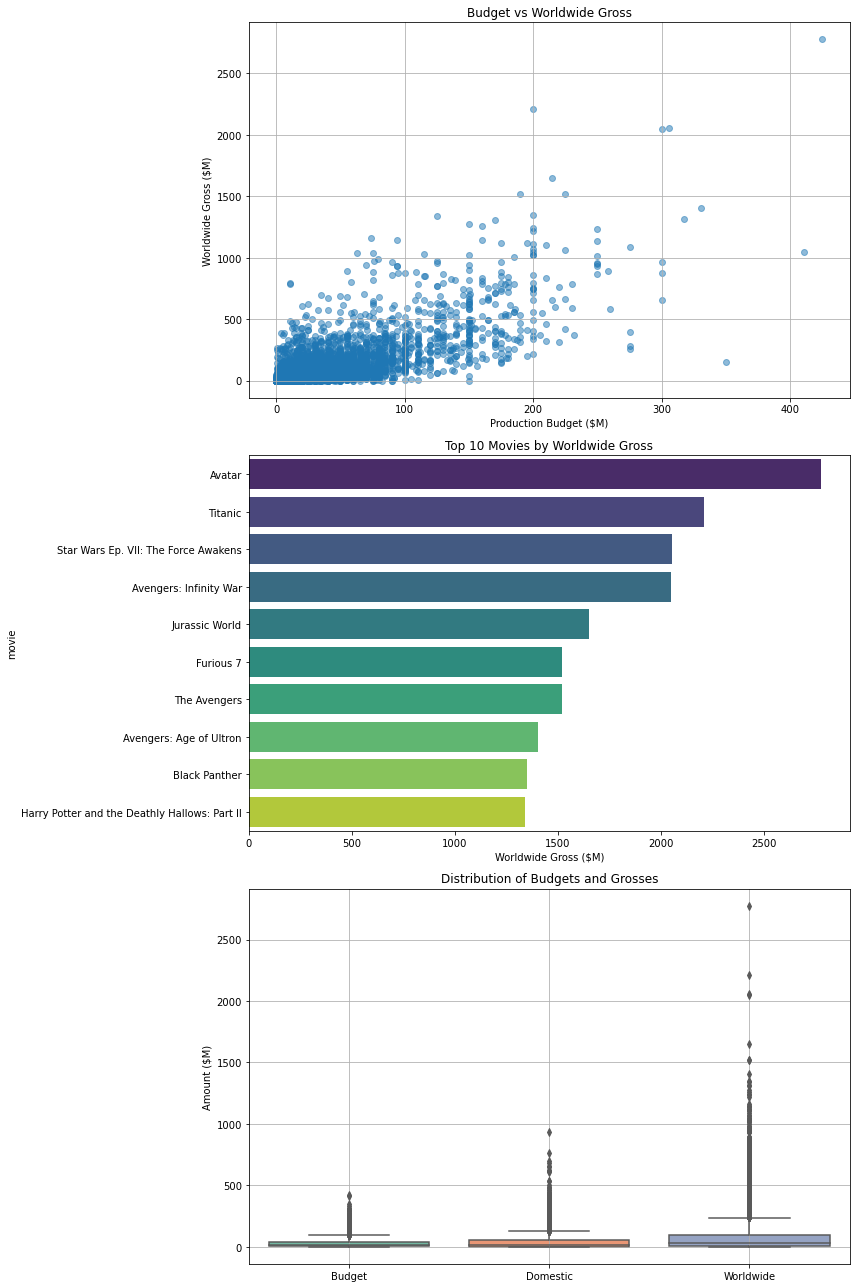

In [25]:
# Clean monetary columns
tn_movie_budgets['production_budget'] = tn_movie_budgets['production_budget'].replace('[\$,]', '', regex=True).astype(float)
tn_movie_budgets['domestic_gross'] = tn_movie_budgets['domestic_gross'].replace('[\$,]', '', regex=True).astype(float)
tn_movie_budgets['worldwide_gross'] = tn_movie_budgets['worldwide_gross'].replace('[\$,]', '', regex=True).astype(float)

# Adjust height to accommodate 3 rows
plt.figure(figsize=(12, 18))  

# 1. Scatter plot: Budget vs Worldwide Gross
plt.subplot(3, 1, 1)
plt.scatter(tn_movie_budgets['production_budget'] / 1e6, tn_movie_budgets['worldwide_gross'] / 1e6, alpha=0.5)
plt.xlabel('Production Budget ($M)')
plt.ylabel('Worldwide Gross ($M)')
plt.title('Budget vs Worldwide Gross')
plt.grid(True)

# 2. Bar plot: Top 10 movies by worldwide gross
top_10 = tn_movie_budgets.nlargest(10, 'worldwide_gross')
plt.subplot(3, 1, 2)
sns.barplot(x=top_10['worldwide_gross'] / 1e6, y=top_10['movie'], palette='viridis')
plt.xlabel('Worldwide Gross ($M)')
plt.title('Top 10 Movies by Worldwide Gross')

# 3. Box plot: Distribution of budgets and grosses
plt.subplot(3, 1, 3)
sns.boxplot(data=[
    tn_movie_budgets['production_budget'] / 1e6,
    tn_movie_budgets['domestic_gross'] / 1e6,
    tn_movie_budgets['worldwide_gross'] / 1e6
], palette='Set2')
plt.xticks([0, 1, 2], ['Budget', 'Domestic', 'Worldwide'])
plt.ylabel('Amount ($M)')
plt.title('Distribution of Budgets and Grosses')
plt.grid(True)

# Adjust layout and display
plt.tight_layout()
plt.savefig("movie_budgets_analysis_vertical.png")
plt.show()


## 🎬 Comparing the ratings to runtime

We explore the `rt_movie_info` and `rt_reviews` datasets from Rotten Tomatoes. Our aim is to analyze:
- How movie ratings relate to other variables like runtime or studio
- Whether critical reception aligns with profitability


## Brief overview
Check the shape, size and columns of the `rt_movie_info` and `rt_reviews` datsets

In [26]:
rt_reviews.head()

,id,review,rating,fresh,critic,top_critic,publisher,date
0,3,A distinctly gallows take on contemporary fina...,3/5,fresh,PJ Nabarro,0,Patrick Nabarro,"November 10, 2018"
1,3,It's an allegory in search of a meaning that n...,NaN,rotten,Annalee Newitz,0,io9.com,"May 23, 2018"
2,3,... life lived in a bubble in financial dealin...,NaN,fresh,Sean Axmaker,0,Stream on Demand,"January 4, 2018"
3,3,Continuing along a line introduced in last yea...,NaN,fresh,Daniel Kasman,0,MUBI,"November 16, 2017"
4,3,... a perverse twist on neorealism...,NaN,fresh,NaN,0,Cinema Scope,"October 12, 2017"


In [27]:
rt_movie_info.head()

,id,synopsis,rating,genre,director,writer,theater_date,dvd_date,currency,box_office,runtime,studio
0,1,"This gritty, fast-paced, and innovative police...",R,Action and Adventure|Classics|Drama,William Friedkin,Ernest Tidyman,"Oct 9, 1971","Sep 25, 2001",NaN,NaN,104 minutes,NaN
1,3,"New York City, not-too-distant-future: Eric Pa...",R,Drama|Science Fiction and Fantasy,David Cronenberg,David Cronenberg|Don DeLillo,"Aug 17, 2012","Jan 1, 2013",$,"600,000",108 minutes,Entertainment One
2,5,Illeana Douglas delivers a superb performance ...,R,Drama|Musical and Performing Arts,Allison Anders,Allison Anders,"Sep 13, 1996","Apr 18, 2000",NaN,NaN,116 minutes,NaN
3,6,Michael Douglas runs afoul of a treacherous su...,R,Drama|Mystery and Suspense,Barry Levinson,Paul Attanasio|Michael Crichton,"Dec 9, 1994","Aug 27, 1997",NaN,NaN,128 minutes,NaN
4,7,NaN,NR,Drama|Romance,Rodney Bennett,Giles Cooper,NaN,NaN,NaN,NaN,200 minutes,NaN


In [28]:
rt_movie_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1560 entries, 0 to 1559
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            1560 non-null   int64 
 1   synopsis      1498 non-null   object
 2   rating        1557 non-null   object
 3   genre         1552 non-null   object
 4   director      1361 non-null   object
 5   writer        1111 non-null   object
 6   theater_date  1201 non-null   object
 7   dvd_date      1201 non-null   object
 8   currency      340 non-null    object
 9   box_office    340 non-null    object
 10  runtime       1530 non-null   object
 11  studio        494 non-null    object
dtypes: int64(1), object(11)
memory usage: 146.4+ KB


### Ratings data analysis
To investigate ratings data to see if factors such as Genre, Runtime and Publisher scores correlate.
We attempt to find how and to what extent they relate to each other
Clean the 'rt_movie_info' dataset
We sart by preparing the data.

In [29]:

# Step 1: Keep only specified columns in the rt_movie_info DataFrame
keep_columns_movie_info = ['id', 'genre', 'runtime', 'studio', 'box_office']
df_movie_info = rt_movie_info [keep_columns_movie_info]
df_movie_info.head()

,id,genre,runtime,studio,box_office
0,1,Action and Adventure|Classics|Drama,104 minutes,NaN,NaN
1,3,Drama|Science Fiction and Fantasy,108 minutes,Entertainment One,"600,000"
2,5,Drama|Musical and Performing Arts,116 minutes,NaN,NaN
3,6,Drama|Mystery and Suspense,128 minutes,NaN,NaN
4,7,Drama|Romance,200 minutes,NaN,NaN


In [30]:
# id: Convert to integer, drop rows with missing id
df_movie_info = df_movie_info.dropna(subset=['id'])
df_movie_info['id'] = df_movie_info['id'].astype(int)


In [31]:
# genre: Strip whitespace, capitalize, fill missing with 'Unknown'
df_movie_info['genre'] = df_movie_info['genre'].str.strip().str.capitalize().fillna('Unknown')

In [32]:

# runtime: Extract number from 'X minutes', fill missing with median, convert to integer
def clean_runtime(runtime):
    if pd.isna(runtime):
        return None
    try:
        # Extract number from 'X minutes'
        return int(runtime.split()[0])
    except (ValueError, AttributeError):
        return None

df_movie_info['runtime'] = df_movie_info['runtime'].apply(clean_runtime)
median_runtime = df_movie_info['runtime'].median()
df_movie_info['runtime'] = df_movie_info['runtime'].fillna(median_runtime).astype(int)


In [33]:
# studio: Strip whitespace, title case, fill missing with 'Unknown'
df_movie_info['studio'] = df_movie_info['studio'].str.strip().str.title().fillna('Unknown')

In [34]:
# box_office: Remove currency symbols, handle commas, fill missing with 0, convert to integer
def clean_box_office(box):
    if pd.isna(box) or box == '':
        return 0
    try:
        # Remove '$' and commas, convert to integer
        return int(str(box).replace('$', '').replace(',', ''))
    except ValueError:
        return 0

df_movie_info['box_office'] = df_movie_info['box_office'].apply(clean_box_office).astype(int)

In [35]:
rt_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54432 entries, 0 to 54431
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          54432 non-null  int64 
 1   review      48869 non-null  object
 2   rating      40915 non-null  object
 3   fresh       54432 non-null  object
 4   critic      51710 non-null  object
 5   top_critic  54432 non-null  int64 
 6   publisher   54123 non-null  object
 7   date        54432 non-null  object
dtypes: int64(2), object(6)
memory usage: 3.3+ MB


###  rt_reviews analysis
Change rating to numeric values i.e. integers for analysis. Ensure missing values are removed from the dataset. Merge with movie_info dataset in order to perfom analysis.

In [36]:
# Ensure 'rating' is numeric
rt_reviews['rating'] = pd.to_numeric(rt_reviews['rating'], errors='coerce')

# Drop rows with NaN in 'rating'
rt_reviews = rt_reviews.dropna(subset=['rating'])

# Convert 'rating' to integer for consistency with 'runtime'
rt_reviews['rating'] = rt_reviews['rating'].astype(int)



In [37]:

# Merge on id
merged_df = pd.merge(rt_reviews, df_movie_info, left_on='id', right_on='id', how='inner')
merged_df.head(10)

,id,review,rating,fresh,critic,top_critic,publisher,date,genre,runtime,studio,box_office
0,3,"... a movie about a sentient zombie, trapped i...",8,fresh,Philip Martin,0,Arkansas Democrat-Gazette,"September 7, 2012",Drama|science fiction and fantasy,108,Entertainment One,600000
1,8,NaN,6,rotten,Brian Webster,0,Apollo Guide,"July 24, 2001",Drama|kids and family,95,Warner Bros. Pictures,0
2,10,If all you're looking for is a mild comedy wit...,6,rotten,Scott Weinberg,0,Apollo Guide,"March 16, 2004",Comedy,82,Paramount Pictures,41032915
3,10,There's probably a sweet little comedy hidden ...,6,rotten,Brian Webster,0,Apollo Guide,"June 12, 2002",Comedy,82,Paramount Pictures,41032915
4,13,"While it's most certainly not light viewing, a...",8,fresh,Brian Webster,0,Apollo Guide,"October 3, 2007",Drama,123,Sony Pictures Classics,224114
5,13,I do just what I want to do/ I want everything...,8,fresh,Philip Martin,0,Arkansas Democrat-Gazette,"June 29, 2007",Drama,123,Sony Pictures Classics,224114
6,17,Tupac's evolution as an artist showed us a you...,7,fresh,Dan Jardine,0,Cinemania,"September 12, 2012",Unknown,100,Unknown,0
7,17,The film would have been strengthened if it ha...,7,fresh,Dan Jardine,0,Apollo Guide,"August 24, 2004",Unknown,100,Unknown,0
8,23,"If American Hustle has anything real to say, i...",3,fresh,Bill Newcott,0,AARP Movies for Grownups,"April 18, 2016",Drama,129,Sony Pictures,99165609
9,23,Russell's world view is essentially optimistic...,8,fresh,Dan Jardine,0,Cinemania,"January 12, 2014",Drama,129,Sony Pictures,99165609


In [38]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 750 entries, 0 to 749
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          750 non-null    int64 
 1   review      651 non-null    object
 2   rating      750 non-null    int32 
 3   fresh       750 non-null    object
 4   critic      733 non-null    object
 5   top_critic  750 non-null    int64 
 6   publisher   747 non-null    object
 7   date        750 non-null    object
 8   genre       750 non-null    object
 9   runtime     750 non-null    int32 
 10  studio      750 non-null    object
 11  box_office  750 non-null    int32 
dtypes: int32(3), int64(2), object(7)
memory usage: 67.4+ KB


## 🍅 Rotten Tomatoes Ratings Analysis

We cleaned and merged the `rt_reviews` and `rt_movie_info` datasets using movie `id`. This allowed us to explore relationships between movie ratings, runtime, and publisher reviews. We construct the following visualizations:

- **Scatter Plot** Shows the distributon of runtime against the rating.
- **Bar Plot**  Shows the average Runtime by Rating.
- **Boxplot** Shows Ratings by Publisher

Thesep plots help to identify patterns in critical reviews based on runtime or reviewing source.


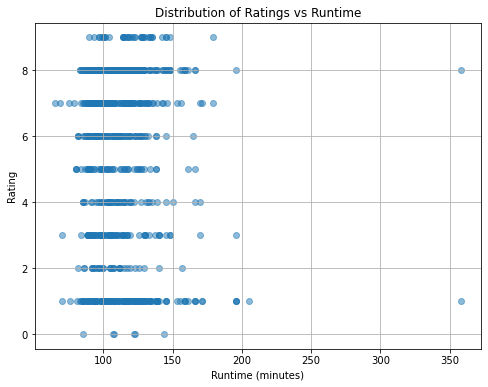

In [39]:
#plotting the distribution of ratings vs runtime
plt.figure(figsize=(8, 6))
plt.scatter(merged_df['runtime'], merged_df['rating'], alpha=0.5)
plt.title('Distribution of Ratings vs Runtime')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Rating')
plt.grid(True)
plt.show()


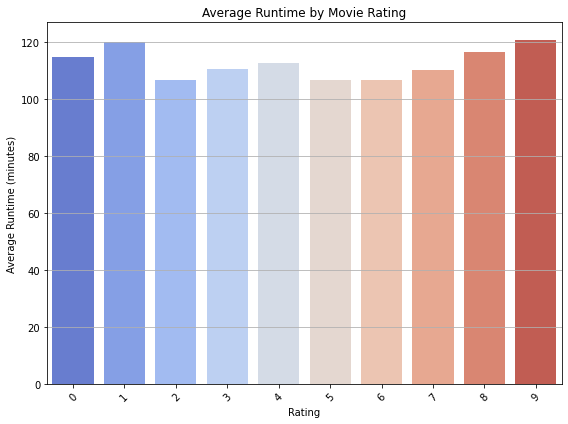

In [40]:


# Drop missing values in 'runtime' and 'rating'
clean_df = merged_df.dropna(subset=['runtime', 'rating'])

# Group by rating and calculate average runtime
avg_runtime = clean_df.groupby('rating')['runtime'].mean().sort_values()

# Plot bar graph
plt.figure(figsize=(8, 6))
sns.barplot(x=avg_runtime.index, y=avg_runtime.values, palette='coolwarm')
plt.title('Average Runtime by Movie Rating')
plt.xlabel('Rating')
plt.ylabel('Average Runtime (minutes)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

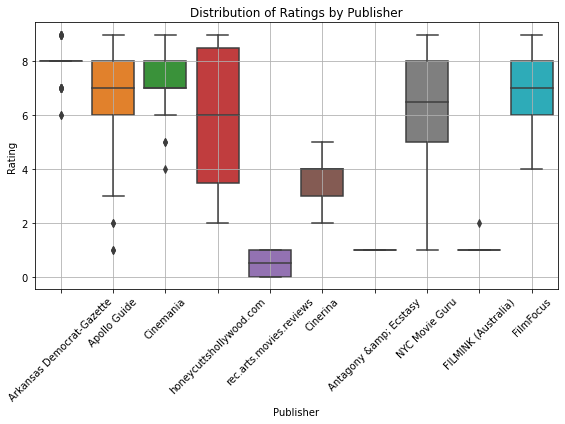

In [41]:

# Handle NaN values in the 'publisher' column
merged_df['publisher'] = merged_df['publisher'].fillna('Unknown')

# Extract the top 10 publishers based on the number of reviews
top_publishers = merged_df['publisher'].value_counts().nlargest(10).index
# Filter the DataFrame to include only the top publishers
merged_df_top_publishers = merged_df[merged_df['publisher'].isin(top_publishers)]
# Plotting the distribution of ratings vs publisher
plt.figure(figsize=(8, 6))
sns.boxplot(x='publisher', y='rating', data=merged_df_top_publishers)
plt.xticks(rotation=45)
plt.title('Distribution of Ratings by Publisher')
plt.xlabel('Publisher')
plt.ylabel('Rating')
plt.grid(True)
plt.tight_layout()
plt.show()


### Key Findings:
- **Scatter Plot:** Showed that most movies fall within a typical runtime range (80–120 minutes), and their ratings vary with some outliers.
- **Bar Plot of Avg. Runtime by Rating:** Indicates that higher-rated films tend to be slightly longer on average.
- **Boxplot of Ratings by Publisher:** Shows potential bias across different review publishers.

These insights can help identify patterns in critical reception based on runtime or reviewing source.

## 4.Statistical analysis.
To confirm our insights we conduct statisctical analysis to confirm whether our conclusions are valid.These incluse:

**linear regression**  and **Z test**

In this section we use different statistical packages in python namely "sklearn", "scipy" and "statsmodels"

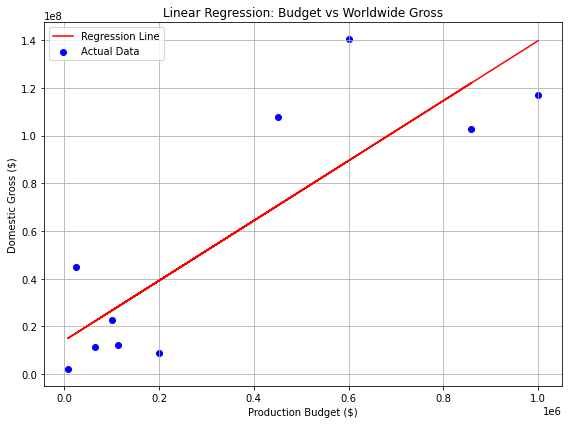

In [42]:

from sklearn.linear_model import LinearRegression

#Prepare data
top_10_profitable = tn_movie_budgets.sort_values(by='ROI', ascending=False).head(10)
budget = top_10_profitable['production_budget'].values.reshape(-1, 1)
gross = top_10_profitable['domestic_gross'].values

#Fit linear regression
model = LinearRegression()
model.fit(budget, gross)
predicted_gross = model.predict(budget)

#Plot
plt.figure(figsize=(8, 6))
plt.scatter(budget, gross, color='blue', label='Actual Data')
plt.plot(budget, predicted_gross, color='red', label='Regression Line')

plt.xlabel('Production Budget ($)')
plt.ylabel('Domestic Gross ($)')
plt.title('Linear Regression: Budget vs Worldwide Gross')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



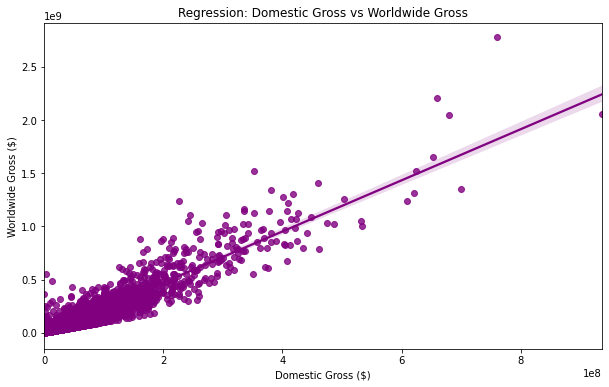

In [43]:
plt.figure(figsize=(10, 6))
sns.regplot(x='domestic_gross', y='worldwide_gross', data=tn_movie_budgets, color='purple')
plt.title('Regression: Domestic Gross vs Worldwide Gross')
plt.xlabel('Domestic Gross ($)')
plt.ylabel('Worldwide Gross ($)')
plt.show()

## Conclusion
This shows that there's a **positive correlation**.
Positive Correlation:
The regression line typically slopes upward, indicating a positive relationship — as domestic gross increases, worldwide gross tends to increase too.

Fit of the Line (Rough Visual R²):
If most of the data points hug the regression line closely, the relationship is strong, and domestic gross is a good predictor of worldwide gross.
If the points are widely scattered, the relationship is weaker, and other factors (like international appeal, genre, or marketing) also play a big role.

**Outliers**:
You can see some movies far above the line, it means those films performed much better internationally than locally.
If a few are below the line, those movies underperformed internationally compared to their domestic performance.

In [44]:
# Check if the line is a fit for the dataset
from sklearn.metrics import r2_score

r2 = r2_score(gross, predicted_gross)
print(f"R² score: {r2:.2f}")

R² score: 0.73


**Adjusted R2** If the R2 is close or equal to 1, it is moderately correlated. The fit is good.

In [45]:
# Conducting a z-test
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import statsmodels.stats.proportion as smp
import statsmodels.stats.weightstats as sw
import statsmodels.stats.multitest as smm
import statsmodels.stats.diagnostic as smd
mean_rating = merged_df['rating'].mean()
std_rating = merged_df['rating'].std()
n = len(merged_df['rating'])

# Calculate the standard error
standard_error = std_rating / np.sqrt(n)

# Calculate the z-score
z_score = (mean_rating - 0) / standard_error 

# Calculate the p-value
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))  
print(f"Z-score: {z_score:.2f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject the null hypothesis: The mean rating is significantly different from 0.")
else:
    print("Fail to reject the null hypothesis: The mean rating is not significantly different from 0.")



Z-score: 50.68
P-value: 0.0000
Reject the null hypothesis: The mean rating is significantly different from 0.


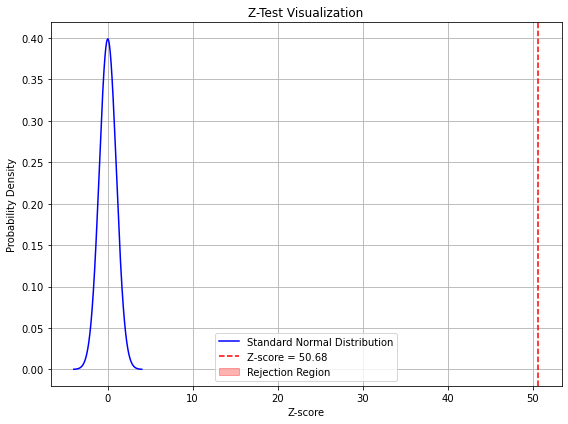

In [46]:
from scipy.stats import norm

# Generate data for the standard normal distribution
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, 0, 1)

# Plot the standard normal distribution
plt.figure(figsize=(8, 6))
plt.plot(x, y, label='Standard Normal Distribution', color='blue')

# Highlight the z-score
plt.axvline(z_score, color='red', linestyle='--', label=f'Z-score = {z_score:.2f}')
plt.fill_between(x, 0, y, where=(x >= z_score), color='red', alpha=0.3, label='Rejection Region')

# Add labels and legend
plt.title('Z-Test Visualization')
plt.xlabel('Z-score')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

### Genre against rating analysis (SQL)
In this part we use the im.db data whish is in SQL format to compare the movie ratings with the genre of the movie.
Since we had loaded the datast before we get into it to view the tables. Here we join tables, compare and provide visuaizations.

In [47]:
# IMDB file

pd.read_sql("""SELECT name FROM sqlite_master WHERE type='table';
            """, conn)

,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [48]:
pd.read_sql("""SELECT * FROM movie_basics;
            """, conn)

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"
...,...,...,...,...,...,...
146139,tt9916538,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,2019,123.0,Drama
146140,tt9916622,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,2015,NaN,Documentary
146141,tt9916706,Dankyavar Danka,Dankyavar Danka,2013,NaN,Comedy
146142,tt9916730,6 Gunn,6 Gunn,2017,116.0,None


In [49]:
pd.read_sql("""SELECT * FROM movie_ratings;
            """, conn)

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21
...,...,...,...
73851,tt9805820,8.1,25
73852,tt9844256,7.5,24
73853,tt9851050,4.7,14
73854,tt9886934,7.0,5


In [50]:
pd.read_sql("""SELECT * FROM movie_ratings WHERE averagerating IS NULL;
            """, conn)

,movie_id,averagerating,numvotes


In [51]:
#Join the two tables to compare genre to average ratings

top_ten_movie_genres = pd.read_sql(""" SELECT mb.genres, mr.averagerating AS genre_rating
                                        FROM movie_basics mb
                                        JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
                                        WHERE mb.genres IS NOT NULL
                                        GROUP BY mb.genres
                                        ORDER BY genre_rating DESC
                                        LIMIT 10;

                                    """, conn)
top_ten_movie_genres

,genres,genre_rating
0,"Documentary,Family,Romance",9.7
1,"Comedy,Documentary,Sport",9.7
2,"Comedy,Documentary,Fantasy",9.4
3,"Documentary,Family,Musical",9.3
4,"History,Sport",9.2
5,"Documentary,History,War",9.2
6,"Crime,Documentary,Drama",9.2
7,"Action,Documentary,Sport",9.2
8,"Comedy,Documentary,Romance",9.1
9,War,9.0


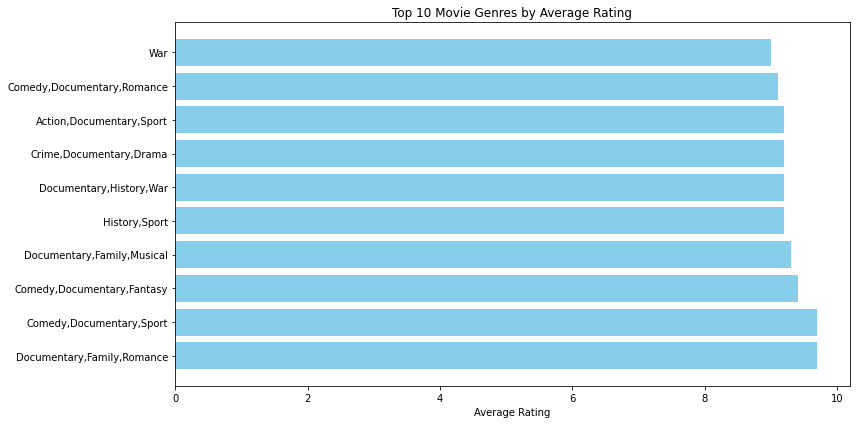

In [52]:
plt.figure(figsize=(12, 6))
plt.barh(top_ten_movie_genres['genres'], top_ten_movie_genres['genre_rating'], color='skyblue')
plt.xlabel('Average Rating')
plt.title('Top 10 Movie Genres by Average Rating')
plt.tight_layout()
plt.show()

In [53]:
runtime_rating =""" SELECT 
                    CASE 
                        WHEN mb.runtime_minutes <= 60 THEN '0–60 mins'
                        WHEN mb.runtime_minutes <= 90 THEN '61–90 mins'
                        WHEN mb.runtime_minutes <= 120 THEN '91–120 mins'
                        WHEN mb.runtime_minutes <= 150 THEN '121–150 mins'
                        ELSE '150+ mins'
                    END AS runtime_range,
                        AVG(mr.averagerating) AS runtime_vs_rating
                    FROM movie_basics mb
                    JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
                    WHERE mb.runtime_minutes IS NOT NULL
                    GROUP BY runtime_range
                    ORDER BY runtime_vs_rating DESC
                    LIMIT 10; """
df = pd.read_sql(runtime_rating, conn)
df

,runtime_range,runtime_vs_rating
0,0–60 mins,7.116484
1,150+ mins,6.705601
2,121–150 mins,6.418887
3,91–120 mins,6.246249
4,61–90 mins,6.231988


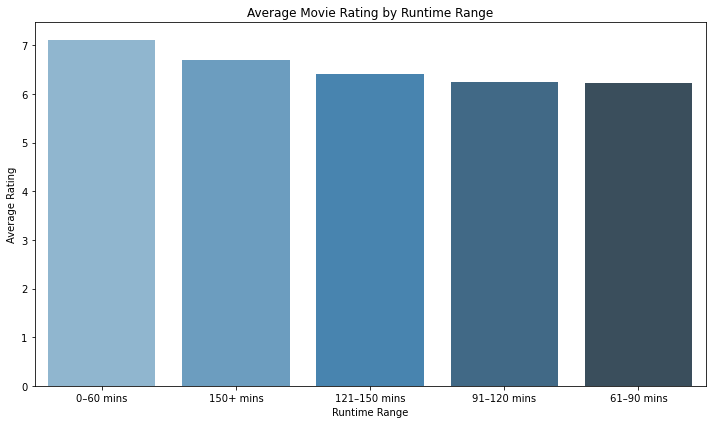

In [54]:
# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='runtime_range',
    y='runtime_vs_rating',
    data=df,
    palette='Blues_d'
)
plt.title('Average Movie Rating by Runtime Range')
plt.xlabel('Runtime Range')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

## 5. Final Insights & Recommendations

### Key Takeaways:
- **Financial Data:** Comparing budget with worldwide gross can be viewed usng either 'Profit' or 'ROI'.
- **Ratings Data:** No clear-cut relationship between runtime and rating, but publishers show different scoring behaviors.
- **Visualizations:** Scatter and regression plots confirmed positive correlations between budget and gross revenue, more specifically domestically and worldwide.
- **Merged Dataset Value:** Combining attributes of (TMDb, RT) with financials (The Numbers) enriched analysis.

### Recommendations:
1. 🎯 When assessing a movie's success, consider both domestic and international performance.
2. ✅ Focus on movies with highest worldwide and domestic gross.
3. 🔍 Consider reviewer source when analyzing ratings — some publishers are more generous than others since opinions are undisputed and depend on a publishers's point of view.

# 6. Limitations
1. Combining attributes from differnt datasets leads to the loss of some several rows of data that could have had an impact on the study.
2. Some financial data on the worlwide and domestic gross may be skewed due to copyright infringment and pirating.